<a href="https://colab.research.google.com/github/evergreen700/comp559-brca-graph/blob/main/COMP559_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Load Libraries

In [1]:
# Install PyG dependencies first
!pip install omnipath torch-scatter torch-sparse torch-cluster torch-spline-conv -f https://data.pyg.org/whl/torch-2.1.0+cu121.html

#Then install torch-geometric
!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.1.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.0/210.0 kB 16.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 kB 5.5 MB/s eta 0:00:00
ERROR: Operation cancelled by user
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.0 MB/s eta 0:00:00
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File 

In [2]:
import requests
import json
import pandas as pd
import io
import tarfile, os, gzip
import glob
import numpy as np
from google.colab import drive
from sklearn.preprocessing import StandardScaler
import omnipath as op

# Download TCGA-BRCA data and save to Google Drive

Steps:


1.   Query GDC for bulk RNA-seq file names
2.   Download files in batches of 200 with POST request
3.   Query GDC to get primary tumor file names
4.   Read in downloaded TSV files and merge them together if ID is from primary tumor
5.   Drop duplicates (not sure why there are duplicates...they weren't that many and the expression value were not highly correlated, so I just dropped them)

6.   Standardize expression values across patients
7.   Download clinical data
8.   Download DoRothEA dataset
9.   Filter expression matrix and DoRothEA to overlapping genes
10.  Merge filtered and standardized expression matrix with clinical data
11.  Save merged patient dataframe and filtered DoRothEA dataframe to Google Drive


## Download Expression Data

### 1) Query GDC for TCGA-BRCA RNA-seq files

In [ ]:
# GDC_FILES   = "https://api.gdc.cancer.gov/files"
# GDC_DATA    = "https://api.gdc.cancer.gov/data"

# filters = {
#     "op": "and",
#     "content": [
#         {"op": "=", "content": {"field": "cases.project.project_id",
#                                 "value": "TCGA-BRCA"}},
#         {"op": "=", "content": {"field": "data_type",
#                                 "value": "Gene Expression Quantification"}},
#         {"op": "=", "content": {"field": "analysis.workflow_type",
#                                 "value": "STAR - Counts"}},
#         {"op": "=", "content": {"field": "data_format",
#                                 "value": "TSV"}},
#         # Primary tumour samples only
#         {"op": "=", "content": {"field": "cases.samples.sample_type",
#                                 "value": "Primary Tumor"}},
#     ]
# }

# params = {
#     "filters": json.dumps(filters),
#     "fields":  "file_id,file_name,cases.submitter_id,cases.samples.sample_type",
#     "format":  "JSON",
#     "size":    "1200"
# }

# print("Querying GDC API...")
# resp = requests.get(GDC_FILES, params=params)
# resp.raise_for_status()
# hits = resp.json()["data"]["hits"]
# print(f"Found {len(hits)} files")

# # Build file_id → case_id lookup
# id2case = {}
# for h in hits:
#     case = h.get("cases", [{}])[0].get("submitter_id", h["id"])
#     id2case[h["id"]] = case

# file_ids = list(id2case.keys())

### Download all files in one POST request

In [ ]:
# import tarfile, os, gzip

# CHUNK = 200          # max per request
# os.makedirs("/content/raw_counts", exist_ok=True)

# for i in range(0, len(file_ids), CHUNK):
#     chunk_ids = file_ids[i:i+CHUNK]
#     print(f"Downloading batch {i//CHUNK + 1} / {len(file_ids)//CHUNK + 1} "
#           f"({len(chunk_ids)} files)...")

#     payload  = {"ids": chunk_ids}
#     response = requests.post(
#         GDC_DATA,
#         json    = payload,
#         headers = {"Content-Type": "application/json"},
#         stream  = True
#     )
#     response.raise_for_status()

#     # Save tar archive
#     tar_path = f"/content/raw_counts/batch_{i//CHUNK}.tar"
#     with open(tar_path, "wb") as f:
#         for chunk in response.iter_content(chunk_size=1024*1024):
#             f.write(chunk)

#     # Extract
#     with tarfile.open(tar_path) as tar:
#         tar.extractall("/content/raw_counts/")

#     os.remove(tar_path)

# print("All files downloaded.")

/tmp/ipykernel_11811/1753062560.py:28: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content/raw_counts/")


### Query GDC to get only primary tumor IDs

In [ ]:
# import requests, json, pandas as pd

# GDC_FILES = "https://api.gdc.cancer.gov/files"

# filters = {
#     "op": "and",
#     "content": [
#         {"op": "=", "content": {"field": "cases.project.project_id",  "value": "TCGA-BRCA"}},
#         {"op": "=", "content": {"field": "data_type",                 "value": "Gene Expression Quantification"}},
#         {"op": "=", "content": {"field": "analysis.workflow_type",    "value": "STAR - Counts"}},
#         {"op": "=", "content": {"field": "data_format",               "value": "TSV"}},
#     ]
# }

# params = {
#     "filters": json.dumps(filters),
#     "fields":  "file_id,file_name,cases.submitter_id,cases.samples.sample_type,cases.samples.submitter_id",
#     "format":  "JSON",
#     "size":    "1200"
# }

# resp = requests.get(GDC_FILES, params=params)
# hits = resp.json()["data"]["hits"]

# # Build a lookup: case_id → sample_type
# rows = []
# for h in hits:
#     case    = h.get("cases", [{}])[0]
#     sample  = case.get("samples", [{}])[0]
#     rows.append({
#         "file_id":     h["id"],
#         "case_id":     case.get("submitter_id"),
#         "sample_type": sample.get("sample_type"),
#     })

# file_meta = pd.DataFrame(rows)
# print(file_meta["sample_type"].value_counts())

### Read in TSV files and create expression matrix

In [ ]:
# # Build a set of primary tumour file_ids for fast lookup
# primary_ids = set(
#     file_meta.loc[file_meta["sample_type"] == "Primary Tumor", "file_id"]
# )

# frames = []
# for tsv_path in glob.glob("/content/raw_counts/**/*.tsv", recursive=True):
#     file_id = os.path.basename(os.path.dirname(tsv_path))

#     # Skip if not a primary tumour
#     if file_id not in primary_ids:
#         continue

#     case_id = id2case.get(file_id, None)
#     if case_id is None:
#         continue

#     try:
#         df = pd.read_csv(tsv_path, sep="\t", comment="#",
#                          usecols=["gene_name", "tpm_unstranded"])
#         df = df.dropna(subset=["gene_name"])
#         df = df.set_index("gene_name")["tpm_unstranded"].rename(case_id)
#         frames.append(df)
#     except Exception as e:
#         print(f"Skipping {tsv_path}: {e}")

# print(f"Loaded {len(frames)} primary tumour samples")
# expr = pd.concat(frames, axis=1).T
# expr.index.name = "sample_id"
# print(expr.shape)
# print(f"Duplicates: {expr.index.duplicated().sum()}")

In [ ]:
# Drop duplicates

# expr = expr[~expr.index.duplicated(keep=False)]

# print(expr.shape)
# print(f"Duplicates: {expr.index.duplicated().sum()}")

### Standarize data for cross patient comparison


In [ ]:
# # Step 1: Log transform
# # TPM values are highly skewed (a few highly expressed genes dominate)
# # log1p = log(x+1), the +1 avoids log(0) for zero-expressed genes
# expr_log = np.log1p(expr)

# # Step 2: Standardise across patients (zero mean, unit variance per gene)
# scaler     = StandardScaler()

# expr_scaled = pd.DataFrame(
#     scaler.fit_transform(expr_log),
#     index   = expr_log.index,
#     columns = expr_log.columns
# )

# print(expr_scaled.describe().iloc[:, :5])

## Download Clinical Data

In [ ]:
# #Download clinical + survival data from GDC API ──
# GDC_CASES = "https://api.gdc.cancer.gov/cases"

# clin_params = {
#     "filters": json.dumps({
#         "op": "=",
#         "content": {"field": "project.project_id", "value": "TCGA-BRCA"}
#     }),
#     "fields": ",".join([
#         "submitter_id",
#         "demographic.vital_status",        # vital_status lives here
#         "demographic.days_to_death",       # days_to_death lives here
#         "diagnoses.days_to_last_follow_up",
#         "diagnoses.age_at_diagnosis",
#         "diagnoses.tumor_stage",
#     ]),
#     "format": "JSON",
#     "size":   "1200"
# }

# print("Downloading clinical data...")

# resp  = requests.get(GDC_CASES, params=clin_params)
# hits  = resp.json()["data"]["hits"]

# rows = []
# for hit in hits:
#     demo  = hit.get("demographic", {})
#     diag  = hit.get("diagnoses", [{}])[0]

#     vital  = demo.get("vital_status", None)
#     death  = demo.get("days_to_death", None)
#     follow = diag.get("days_to_last_follow_up", None)

#     duration = death if (vital and vital.lower() == "dead") else follow

#     rows.append({
#         "case_id":  hit["submitter_id"],
#         "vital_status": vital,
#         "duration": duration,
#         "age":      diag.get("age_at_diagnosis", None),
#         "stage":    diag.get("tumor_stage", None),
#     })

# clinical = pd.DataFrame(rows)
# clinical["duration"] = pd.to_numeric(clinical["duration"], errors="coerce")
# clinical["event"] = (clinical["vital_status"] == "Dead").astype(int)
# clinical = clinical.dropna(subset=["duration"])

# print(clinical.shape)

In [ ]:
# # Check how many negative durations exist
# print(f"Clinical before removing negative durations: {clinical.shape}")
# print(f"Negative durations: {(clinical['duration'] < 0).sum()}")
# print(f"Zero durations: {(clinical['duration'] == 0).sum()}")
# print(clinical[clinical['duration'] < 0][['case_id','vital_status','duration']])

# # Remove them
# clinical = clinical[clinical['duration'] > 0].reset_index(drop=True)
# print(f"Clinical after removing negative durations: {clinical.shape}")

## Download DoRothEA data

In [ ]:
# # Pull DoRothEA with gene symbols ──
# dorothea_raw = op.interactions.Dorothea.get(
#     dorothea_levels = ['A', 'B', 'C'],
#     organism        = "human",
#     genesymbols     = True          # ← this gives gene names instead of UniProt IDs
# )

# # Build clean DoRothEA dataframe with gene symbols and regulatory weight ──
# dorothea = dorothea_raw[['source_genesymbol', 'target_genesymbol',
#                           'consensus_stimulation', 'consensus_inhibition']].copy()

# # Rename to match rest of pipeline
# dorothea = dorothea.rename(columns={
#     'source_genesymbol': 'source',
#     'target_genesymbol': 'target'
# })

# # +1 = activation, -1 = repression, 0 = unknown/conflicting
# dorothea['weight'] = dorothea['consensus_stimulation'].astype(int) - \
#                      dorothea['consensus_inhibition'].astype(int)

# # Drop any edges with unknown regulatory direction (weight == 0)
# dorothea = dorothea[dorothea['weight'] != 0]

# # Drop duplicates
# dorothea = dorothea[['source', 'target', 'weight']].drop_duplicates().reset_index(drop=True)

# print(f"Total edges:    {len(dorothea)}")
# print(f"Unique TFs:     {dorothea['source'].nunique()}")
# print(f"Unique targets: {dorothea['target'].nunique()}")
# print(f"\nWeight distribution:")
# print(dorothea['weight'].value_counts())
# print(dorothea.head(10))

### Align DoRothEA genes to expression matrix

In [ ]:
# # Get all genes mentioned in DoRothEA (both TFs and targets)
# grn_genes  = set(dorothea['source']) | set(dorothea['target'])
# expr_genes  = set(expr_scaled.columns)
# keep_genes  = sorted(grn_genes & expr_genes)

# print(f"Genes in DoRothEA:          {len(grn_genes)}")
# print(f"Genes in expression matrix: {len(expr_genes)}")
# print(f"Genes in common:            {len(keep_genes)}")

# # Filter expression matrix to only GRN genes
# expr_grn = expr_scaled[keep_genes]

# # Filter DoRothEA edges to only those where BOTH endpoints are in expression matrix
# mask          = dorothea['source'].isin(keep_genes) & dorothea['target'].isin(keep_genes)
# dorothea_filt = dorothea[mask].reset_index(drop=True)

# print(f"\nEdges after filtering: {len(dorothea_filt)}")
# print(f"TFs after filtering:   {dorothea_filt['source'].nunique()}")

## Merge data and save to Google Drive

In [ ]:
# drive.mount("/content/drive")

# SAVE = "/content/drive/MyDrive/TCGA_BRCA_GNN/"
# os.makedirs(SAVE, exist_ok=True)

# # Merge expression + survival on case ID
# merged = expr_grn.join(
#     clinical.set_index("case_id")[["event","duration","age","stage"]],
#     how="inner"
# )

# print(f"Final dataset: {merged.shape}")
# print(f"Deaths: {int(merged['event'].sum())}")

# # Save
# # clinical.to_csv(f"{SAVE}brca_clinical.csv", index=False)
# merged.to_csv(f"{SAVE}brca_merged.csv")
# dorothea_filt.to_csv(f"{SAVE}dorothea_filt.csv")

# print("Saved to Google Drive.")

# Load Data from Google Drive

In [5]:
drive.mount("/content/drive")

SAVE = "/content/drive/MyDrive/TCGA_BRCA_GNN/"

# clinical = pd.read_csv(f"{SAVE}brca_clinical.csv",   index_col=0)
merged   = pd.read_csv(f"{SAVE}brca_merged.csv",     index_col=0)
dorothea_filt   = pd.read_csv(f"{SAVE}dorothea_filt.csv",     index_col=0)

print(merged.shape)
print(dorothea_filt.shape)

Mounted at /content/drive
(984, 1603)
(2965, 3)


# Set Up GNN

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
ERROR: Operation cancelled by user
^C


In [ ]:
# Get all genes in DoRothEA and expression matrix
grn_genes  = set(dorothea_filt['source']) | set(dorothea_filt['target'])
expr_genes  = set(merged.columns)
keep_genes  = sorted(grn_genes & expr_genes)

print(f"Genes in DoRothEA:          {len(grn_genes)}")
print(f"Genes in expression matrix: {len(expr_genes)}")
print(f"Genes in common:            {len(keep_genes)}")


print(f"Edges after filtering: {len(dorothea_filt)}")
print(f"TFs after filtering:   {dorothea_filt['source'].nunique()}")

## Build fixed GRN graph skeleton

In [ ]:
import torch

gene2idx = {gene: idx for idx, gene in enumerate(keep_genes)}
n_genes  = len(keep_genes)

src = dorothea_filt['source'].map(gene2idx).values
dst = dorothea_filt['target'].map(gene2idx).values

edge_index  = torch.tensor(np.stack([src, dst]), dtype=torch.long)
edge_weight = torch.tensor(dorothea_filt['weight'].values, dtype=torch.float)

print(f"Nodes: {n_genes}")
print(f"Edges: {edge_index.shape[1]}")

expr_grn = merged[keep_genes]

Nodes: 1598
Edges: 2965


## Compute patient-specific edge weights

This currently takes in information from other patient graphs that have similar gene expression but I'm working on making it completely patient specific.

We should improve this part by using a learnable message passing function for calculating edge weights

In [ ]:
from sklearn.neighbors import NearestNeighbors

X = expr_grn.values.astype(np.float32)   # (n_patients, n_genes)
src_np = src
dst_np = dst
n_edges = len(src_np)

# k-NN over patients in expression space
K = 30
knn = NearestNeighbors(n_neighbors=K+1, metric='cosine')
knn.fit(X)
_, knn_idx = knn.kneighbors(X)
knn_idx = knn_idx[:, 1:]     # exclude self

static_weights = edge_weight.numpy()

def compute_edge_weights(patient_idx):

    neighbors  = knn_idx[patient_idx]

    context     = np.concatenate([[patient_idx], neighbors])

    local_expr  = X[context]                        # (K+1, n_genes)

    tf_expr     = local_expr[:, src_np]             # (K+1, n_edges)

    tgt_expr    = local_expr[:, dst_np]             # (K+1, n_edges)

    # Pearson correlation per edge across local neighborhood
    tf_z        = tf_expr  - tf_expr.mean(axis=0)
    tgt_z       = tgt_expr - tgt_expr.mean(axis=0)
    num         = (tf_z * tgt_z).sum(axis=0)
    denom       = np.sqrt((tf_z**2).sum(axis=0) * (tgt_z**2).sum(axis=0)) + 1e-8
    coexpr      = num / denom                       # (n_edges,) in [-1, 1]

    # Modulate by DoRothEA regulatory sign
    return (coexpr * static_weights).astype(np.float32)

print("Precomputing patient-specific edge weights...")
n_patients       = X.shape[0]
all_edge_weights = np.zeros((n_patients, n_edges), dtype=np.float32)

for i in range(n_patients):
    all_edge_weights[i] = compute_edge_weights(i)
    if i % 100 == 0:
        print(f"  {i}/{n_patients}")

print("Done.")

Precomputing patient-specific edge weights...
  0/984
  100/984
  200/984
  300/984
  400/984
  500/984
  600/984
  700/984
  800/984
  900/984
Done.


## Build survival labels

In [ ]:
# Make sure merged index aligns with expr_grn
surv_df = merged[['event', 'duration']].copy()
surv_df = surv_df.loc[expr_grn.index]

print(f"Patients:        {len(surv_df)}")
print(f"Events (deaths): {int(surv_df['event'].sum())}")
print(f"Censored:        {int((surv_df['event'] == 0).sum())}")

Patients:        984
Events (deaths): 145
Censored:        839


## PyG Dataset Class

In [ ]:
from torch_geometric.data import Dataset, Data
from sklearn.model_selection import train_test_split

class GRNSurvivalDataset(Dataset):
    def __init__(self, expr, surv, edge_index, edge_weights):
        super().__init__()
        self.x            = torch.tensor(expr.values,            dtype=torch.float)
        self.events       = torch.tensor(surv['event'].values,   dtype=torch.float)
        self.durations    = torch.tensor(surv['duration'].values, dtype=torch.float)
        self.edge_index   = edge_index
        self.edge_weights = torch.tensor(edge_weights,           dtype=torch.float)

    def len(self):
        return self.x.shape[0]

    def get(self, idx):
        return Data(
            x          = self.x[idx].unsqueeze(1),           # (n_genes, 1)
            edge_index = self.edge_index,                     # (2, n_edges)
            edge_attr  = self.edge_weights[idx].unsqueeze(1), # (n_edges, 1)
            y_event    = self.events[idx],
            y_duration = self.durations[idx],
        )

/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cpu.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_cluster/_version_cpu.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_sparse/_version_cpu.so
  import torch_geometric.typing


## GNN Model Class
Kept lightweight for CPU training:
- 2 GATv2 layers instead of 3
- smaller hidden dim (32)
- fewer attention heads (2)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, BatchNorm, global_mean_pool, global_max_pool

class GRNSurvivalGNN(nn.Module):
    def __init__(self, in_channels=1, hidden=32, heads=2, dropout=0.3):
        super().__init__()

        self.conv1 = GATv2Conv(in_channels,    hidden,     heads=heads,
                                edge_dim=1, concat=True,  dropout=dropout)

        self.bn1   = BatchNorm(hidden * heads)

        self.conv2 = GATv2Conv(hidden * heads, hidden,     heads=1,
                                edge_dim=1, concat=False,  dropout=dropout)

        self.bn2   = BatchNorm(hidden)

        # mean + max pooling → hidden * 2 input to MLP
        self.fc = nn.Sequential(
            nn.Linear(hidden * 2, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)        # scalar risk score
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, data):
        x, ei, ea, batch = data.x, data.edge_index, data.edge_attr, data.batch

        x = F.elu(self.bn1(self.conv1(x, ei, ea)))
        x = self.dropout(x)
        x = F.elu(self.bn2(self.conv2(x, ei, ea)))

        # Graph readout
        x_mean = global_mean_pool(x, batch)
        x_max  = global_max_pool(x, batch)
        x_g    = torch.cat([x_mean, x_max], dim=1)

        return self.fc(x_g).squeeze(1)     # (batch,) risk scores

## Cox Loss "Function"

In [ ]:
def cox_ph_loss(risk, durations, events):

    order      = torch.argsort(durations, descending=True)
    risk       = risk[order]
    events     = events[order]
    log_cs     = torch.logcumsumexp(risk, dim=0)
    uncensored = events.bool()
    if uncensored.sum() == 0:
        return torch.tensor(0.0, requires_grad=True)
    return -(risk[uncensored] - log_cs[uncensored]).mean()

# Training GNN

## Split into train/validation/test datasets

In [ ]:
# Split indices
idx = np.arange(len(surv_df))
train_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=42,
    stratify=surv_df['event'].values
)
train_idx, val_idx = train_test_split(
    train_idx, test_size=0.15, random_state=42
)

ew = all_edge_weights
# ew = all_pt_static_weights

train_ds = GRNSurvivalDataset(expr_grn.iloc[train_idx], surv_df.iloc[train_idx], edge_index, ew[train_idx])
val_ds   = GRNSurvivalDataset(expr_grn.iloc[val_idx],   surv_df.iloc[val_idx],   edge_index, ew[val_idx])
test_ds  = GRNSurvivalDataset(expr_grn.iloc[test_idx],  surv_df.iloc[test_idx],  edge_index, ew[test_idx])

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 668 | Val: 119 | Test: 197


In [ ]:
train_ds.get(2).edge_attr

tensor([[ 0.0485],
        [-0.0470],
        [ 0.0832],
        ...,
        [-0.0230],
        [-0.0227],
        [-0.4536]])

In [ ]:
from torch_geometric.loader import DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

# CPU-friendly batch size
BATCH_SIZE = 16

model  = GRNSurvivalGNN()
optim  = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
sched  = CosineAnnealingWarmRestarts(optim, T_0=20, T_mult=2)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

best_val_loss = float('inf')
patience      = 20
no_improve    = 0
SAVE          = "/content/drive/MyDrive/TCGA_BRCA_GNN/"

for epoch in range(1, 151):
    # Train
    model.train()
    train_loss = 0

    for batch in train_loader:

        optim.zero_grad()
        risk  = model(batch)
        loss  = cox_ph_loss(risk, batch.y_duration, batch.y_event)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step()
        train_loss += loss.item()

    # Validate
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            risk      = model(batch)
            val_loss += cox_ph_loss(risk, batch.y_duration, batch.y_event).item()

    sched.step()

    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Train: {avg_train:.4f} | Val: {avg_val:.4f}")

    # Early stopping + save best
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        no_improve    = 0
        torch.save(model.state_dict(), f"{SAVE}best_model.pt")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

print(f"Best val loss: {best_val_loss:.4f}")

Epoch  10 | Train: 1.5011 | Val: 1.5291
Epoch  20 | Train: 1.5755 | Val: 1.5330
Early stopping at epoch 22
Best val loss: 1.5163


# Evaluate GNN on test data

In [ ]:
from lifelines.utils import concordance_index
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

model.load_state_dict(torch.load(f"{SAVE}best_model.pt"))
model.eval()

test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
all_risk, all_dur, all_evt = [], [], []

with torch.no_grad():
    for batch in test_loader:
        risk = model(batch).numpy()
        all_risk.extend(risk)
        all_dur.extend(batch.y_duration.numpy())
        all_evt.extend(batch.y_event.numpy())

all_risk = np.array(all_risk)
all_dur  = np.array(all_dur)
all_evt  = np.array(all_evt)

c_index = concordance_index(all_dur, -all_risk, all_evt)
print(f"Test C-Index: {c_index:.4f}")
# > 0.5 = better than random
# > 0.6 = reasonable for genomics
# > 0.65 = good


Test C-Index: 0.5008


In [ ]:
from lifelines.statistics import logrank_test

# Split into groups as you already did
median = np.median(all_risk)
groups = (all_risk > median).astype(int)

# Log-rank test
mask_low  = groups == 0
mask_high = groups == 1

result = logrank_test(
    all_dur[mask_low], all_dur[mask_high],
    event_observed_A=all_evt[mask_low],
    event_observed_B=all_evt[mask_high]
)

print(f"Log-rank test p-value: {result.p_value:.4e}")

Log-rank test p-value: 9.9632e-01


# Visualize Results with KM Plot

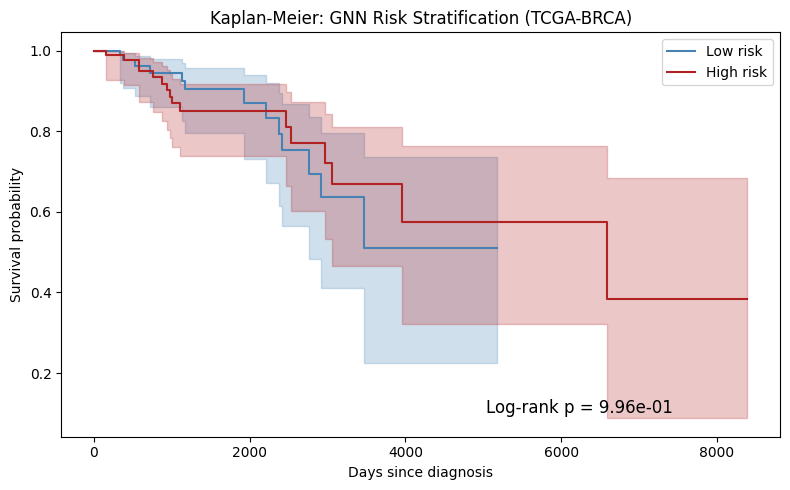

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
kmf = KaplanMeierFitter()

for g, label, color in [(0, 'Low risk', 'steelblue'), (1, 'High risk', 'firebrick')]:
    mask = groups == g
    kmf.fit(all_dur[mask], all_evt[mask], label=label)
    kmf.plot_survival_function(ax=ax, color=color)

ax.set_title("Kaplan-Meier: GNN Risk Stratification (TCGA-BRCA)")
ax.set_xlabel("Days since diagnosis")
ax.set_ylabel("Survival probability")

# Annotate p-value on the plot
ax.text(
    x=0.6 * all_dur.max(),
    y=0.1,
    s=f"Log-rank p = {result.p_value:.2e}",
    fontsize=12
)

plt.tight_layout()
plt.savefig(f"{SAVE}km_curve.png", dpi=150)
plt.show()